# DAY 151 - Training a Custom SDXL LoRA Model
@A.IPYNB

### The Goal
We want to customize Stable Diffusion XL to generate a specific object that it hasn't seen before.

### The Problem with Full Training
SDXL has billions of parameters. Training it from scratch requires clusters of A100 GPUs and weeks of time. Even full fine-tuning (Dreambooth) is too heavy for a free Colab T4 GPU.

### The Solution: LoRA (Low-Rank Adaptation)
Just like in the text example, we don't retrain the whole model. We freeze the massive pre-trained UNet and insert tiny, trainable rank decomposition matrices into the attention layers.

We only train these tiny matrices.
-   **SDXL Size:** ~6.6 GB (fp16)
-   **Our LoRA Size:** ~25 MB

### The Stack
1.  **Base Model:** Stable Diffusion XL 1.0 base.
2.  **Dataset:** A tiny dataset of 5 images of a specific cat toy (from Hugging Face).
3.  **Technique:** LoRA training using the `diffusers` library and `accelerate` for memory management on the T4 GPU.

In [ ]:

# @title 1. Install Dependencies
# IMPORTANT: Click Runtime → Restart Runtime first, then run this cell

!pip install -q torch==2.9.0 torchvision==0.24.0 torchaudio==2.9.0
!pip install -q xformers==0.0.33.post1
!pip install -q accelerate transformers ftfy bitsandbytes peft
!pip install -q git+https://github.com/huggingface/diffusers.git

# diffusers repo
!rm -rf diffusers
!git clone https://github.com/huggingface/diffusers.git

print("Environment set up. Ready for heavy lifting.")

### The Dataset
For this project, we will use a tiny demonstration dataset provided by Hugging Face containing photos of a specific cat toy.

In a real-world scenario, you would replace this with 5-15 high-quality JPEGs of your own subject (your dog, a specific product, your face, etc.), uploaded to a folder in Colab.

### The Concept Token
We need to teach the model a new word associated with these images. We use a rare token combination like `sks` to avoid interfering with existing concepts (e.g., if we just trained it on "toy", it might forget what other toys look like).

**Instance Prompt:** "a photo of sks toy"

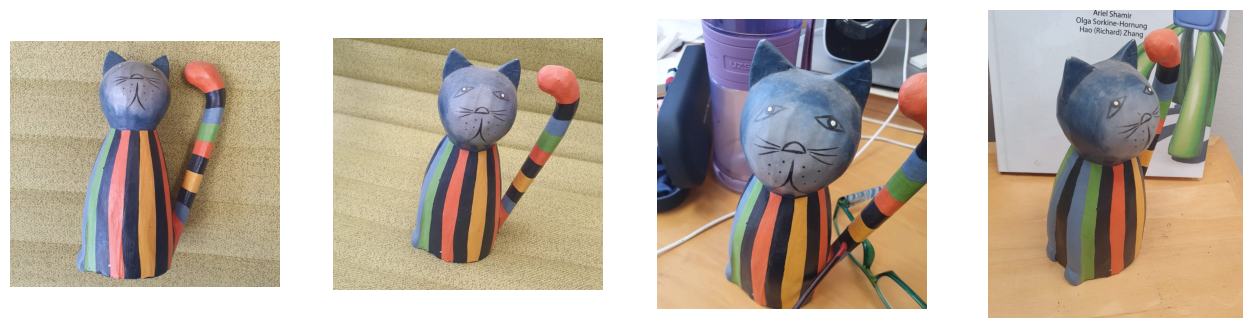

✅ Dataset loaded. Will save to: sdxl-cat-toy-lora


In [7]:
# @title 2. Download and Inspect Data
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset_id = "diffusers/cat_toy_example"
dataset = load_dataset(dataset_id, split="train")

# Displaying sample images
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    ax[i].imshow(dataset[i]["image"])
    ax[i].axis("off")
plt.show()

output_dir = "sdxl-cat-toy-lora"
print(f"✅ Dataset loaded. Will save to: {output_dir}")

### The Training Command
Training SDXL is complex. We use the `accelerate launch` command to handle GPU memory efficiently. We are running an official script from the cloned `diffusers` repository.

### Key Hyperparameters Explained

1.  **`--pretrained_model_name_or_path`**: The base SDXL model we are attaching to.
2.  **`--instance_prompt`**: The magic phrase containing our unique trigger word (`sks toy`).
3.  **`--resolution=1024`**: SDXL loves square 1024x1024 images.
4.  **`--train_batch_size=1`**: Crucial for Colab T4. We can only fit one image at a time in memory.
5.  **`--gradient_accumulation_steps=4`**: Since batch size is 1, we accumulate gradients over 4 steps to simulate a batch size of 4. This stabilizes training.
6.  **`--learning_rate=1e-4`**: The standard starting point for LoRA.
7.  **`--max_train_steps=500`**: How long to train. For 5 images, 500 steps is usually enough to learn the object without severe overfitting.
8.  **`--mixed_precision="fp16"`**: Essential for memory savings.
9.  **`--use_8bit_adam`**: Uses a quantized optimizer to save even more VRAM. This is the key to making SDXL run on a T4.

In [ ]:
# @title 3. Launch Training (Memory Optimized for T4)
%env ALL_PROXY=
%env no_proxy=
%env NO_PROXY=

!accelerate launch diffusers/examples/dreambooth/train_dreambooth_lora_sdxl.py \
  --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0" \
  --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix" \
  --dataset_name=$dataset_id \
  --instance_prompt="a photo of sks toy" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --gradient_checkpointing \
  --mixed_precision="fp16" \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=500 \
  --checkpointing_steps=250 \
  --seed=42 \
  --enable_xformers_memory_efficient_attention \
  --use_8bit_adam \
  --output_dir=$output_dir

### Loading our Custom LoRA
Training is finished. We now have a folder containing `pytorch_lora_weights.safetensors`. This file is small (~25MB) but contains the essence of the cat toy.

To use it, we:
1. Load the base SDXL model.
2. Use the `load_lora_weights` function to inject our trained adapters on top of it.
3. Prompt the model using our trigger phrase `sks toy`.

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


LoRA loaded successfully!


  0%|          | 0/30 [00:00<?, ?it/s]

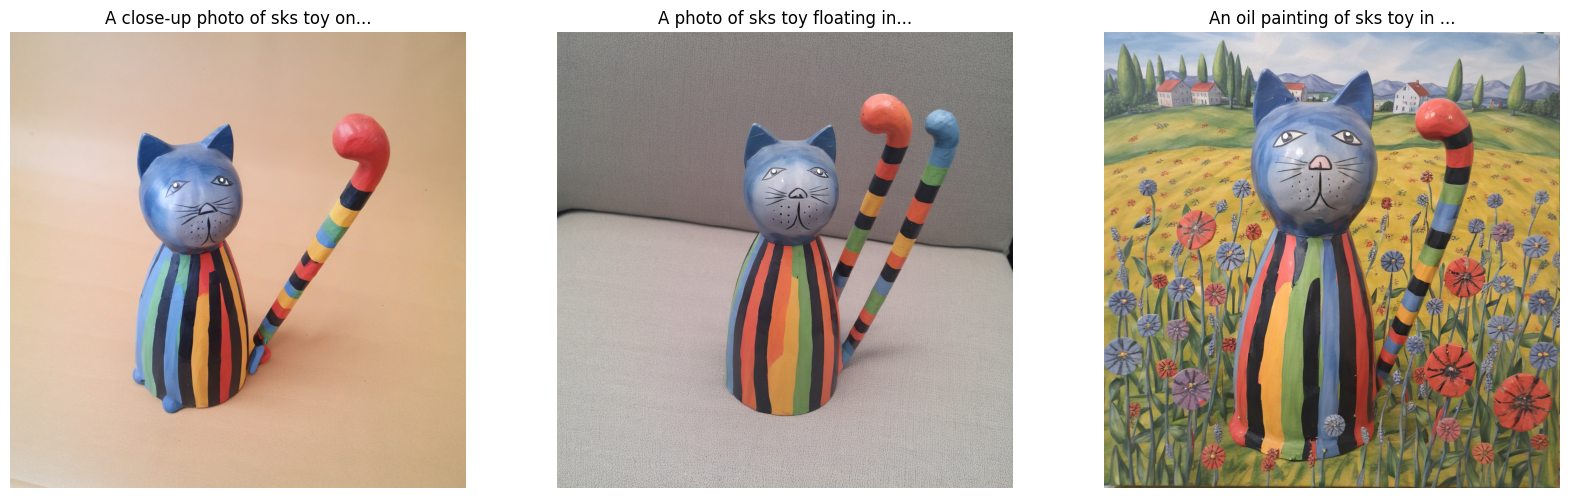

In [9]:
# @title 4. Inference
import torch
from diffusers import StableDiffusionXLPipeline, AutoencoderKL
from peft import PeftModel

# 1. Load the Base Model (SDXL 1.0)
# We load in float16 to fit on the GPU for inference
vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
pipeline = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

# 2. Load our newly trained LoRA weights
# We give it an adapter_name so we can turn it on/off if we want
pipeline.load_lora_weights(output_dir, weight_name="pytorch_lora_weights.safetensors", adapter_name="cat_toy")

print("LoRA loaded successfully!")

# 3. Define Prompts
# We must use our trigger word "sks toy"
prompts = [
    "A close-up photo of sks toy on a wooden desk",
    "A photo of sks toy floating in outer space, cinematic lighting",
    "An oil painting of sks toy in a field of flowers"
]

# 4. Generate
# We use 30 inference steps for good quality
images = pipeline(
    prompt=prompts,
    num_inference_steps=30,
    guidance_scale=7.5,
).images

# 5. Display results
fig, ax = plt.subplots(1, len(images), figsize=(20, 6))
for i, img in enumerate(images):
    ax[i].imshow(img)
    ax[i].set_title(prompts[i][:30] + "...")
    ax[i].axis("off")
plt.show()

### Analysis
Look at the generated images. The model should have successfully placed the exact brown, red-nosed mouse toy into completely new contexts (space, oil painting) while respecting the lighting and style of the prompt.

This is the power of LoRA: high-fidelity concept injection without retraining the underlying foundation model.

### What we can do next
1.  **Download weights:** In the Colab file browser on the left, find the `sdxl-cat-toy-lora` folder. Right-click `pytorch_lora_weights.safetensors` and download it. We can now use this file in automatic1111, ComfyUI, or share it on Hugging Face.
2.  **Try our own data:** Create a folder named `my_data` in Colab. Upload 10 photos of dog. Change the `--dataset_name` argument in the training block to point to the local folder (requires slight script modification for local folders) or upload dataset to Hugging Face hub private repo.